# Plot Model Performance

This section evaluates and visualizes the spatial decoding performance across all three classifiers: KNN, SVC, and Logistic Regression.

For each model and brain hemisphere, we load the actual cross-validation accuracies alongside the null distributions generated from the permutation tests. We then compute the empirical p-values and plot the results. The violin plots represent the chance-level null distributions, while the green scatter points indicate the true predictive accuracy of our trained models.

In [3]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Arial']

DATA_PATH = Path('../data')
RESULT_PATH = Path('../results')
BRAIN_HEMISPHERE_LIST = ['left', 'right']
PLOTS_PATH = Path('../plots')
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')

KNN       left    : n=5, acc=0.6882
permutation test: n=10000, acc=0.3332, p=0.00050
KNN       right   : n=5, acc=0.7156
permutation test: n=10000, acc=0.3333, p=0.00050
SVC       left    : n=5, acc=0.6592
permutation test: n=10000, acc=0.3332, p=0.00050
SVC       right   : n=5, acc=0.6866
permutation test: n=10000, acc=0.3332, p=0.00050
Logistic  left    : n=5, acc=0.6577
permutation test: n=10000, acc=0.3333, p=0.00050
Logistic  right   : n=5, acc=0.7001
permutation test: n=10000, acc=0.3333, p=0.00050


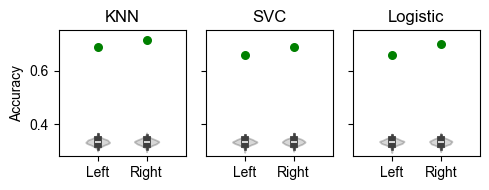

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(5, 2), sharey=True, sharex=True)

for i, model_name in enumerate(['KNN', 'SVC', 'Logistic']):
    data_dict = dict()
    for brain_hemisphere in BRAIN_HEMISPHERE_LIST:
        # Load true accuracies
        acc_path = RESULT_PATH / f'individual/{brain_hemisphere}_{model_name}_acc.pkl'
        acc_list = joblib.load(acc_path)
        mean_acc = np.mean(acc_list)

        # Load and aggregate permutation accuracies (averaging across the 5 folds per permutation)
        permutation_acc_path = RESULT_PATH / f'individual/{brain_hemisphere}_{model_name}_permutation_acc.pkl'
        permutation_acc_list = joblib.load(permutation_acc_path)
        permutation_acc_agg_list = np.array([
            sum(permutation_acc_list[j:j+5]) / len(permutation_acc_list[j:j+5])
            for j in range(0, len(permutation_acc_list), 5)
        ])

        permutation_mean_acc = np.mean(permutation_acc_agg_list)
        permutation_p = (np.sum(permutation_acc_agg_list > mean_acc) + 1) / (len(permutation_acc_agg_list) + 1)

        print(f'{model_name:<10}{brain_hemisphere:<8}: n={len(acc_list)}, acc={mean_acc:.4f}')
        print(f'permutation test: n={len(permutation_acc_list)}, acc={permutation_mean_acc:.4f}, p={permutation_p:.5f}')

        data_dict[brain_hemisphere] = (mean_acc, permutation_acc_agg_list)


    ax = axes[i]

    # 1. Extract permutation distribution data for the violin plot
    dist_left = data_dict['left'][1]
    dist_right = data_dict['right'][1]

    sns.violinplot(data=[dist_left, dist_right], ax=ax, color="gray", width=0.5, cut=0, alpha=0.3)

    # 2. Extract the actual mean accuracy to mark as key points
    acc_left = data_dict['left'][0]
    acc_right = data_dict['right'][0]

    # 3. Scatter plot the actual mean accuracies over the distributions
    # x=0 corresponds to Left, x=1 corresponds to Right
    # zorder=3 ensures the scatter points are drawn above the violin plot
    ax.scatter(
        x=[0, 1],
        y=[acc_left, acc_right],
        color='green',
        marker='o',
        s=30,
        zorder=3
    )

    # 4. Format the plot
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Left', 'Right'])
    ax.set_title(f'{model_name}')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.28, 0.75)
    ax.set_xlim(-0.8, 1.8)


fig.tight_layout()
fig.savefig(PLOTS_PATH / 'individual/model_test.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'individual/model_test.svg', **PLOT_KWARGS_DICT)